## Hands-on Lab: Plotting Directly with Matplotlib


In [1]:
import matplotlib.pyplot as plt # import the scripting interface
import pandas as pd
import numpy as np
plt.style.use( {'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-paper'})

df_can = pd.read_csv("data/Canada.csv", index_col="Country")
years = list(map(str, range(1980,2014)))

df_can

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Viet Nam,Asia,South-Eastern Asia,Developing regions,1191,1829,2162,3404,7583,5907,2741,...,1852,3153,2574,1784,2171,1942,1723,1731,2112,97146
Western Sahara,Africa,Northern Africa,Developing regions,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
Yemen,Asia,Western Asia,Developing regions,1,2,1,6,0,18,7,...,161,140,122,133,128,211,160,174,217,2985


### Line Plot
A line plot displays the relationship between two continuous variables over a continuous interval, showing the trend or pattern of the data.

Let's create a line plot to visualize the immigrants (to Canada) trend during 1980 to 2013.
We need the Total of year-wise immigrants,

We will create a new dataframe for only columns containing the years
then, we will apply sum() on the dataframe

You can do create a line plot directly on axes by calling plot function plot()

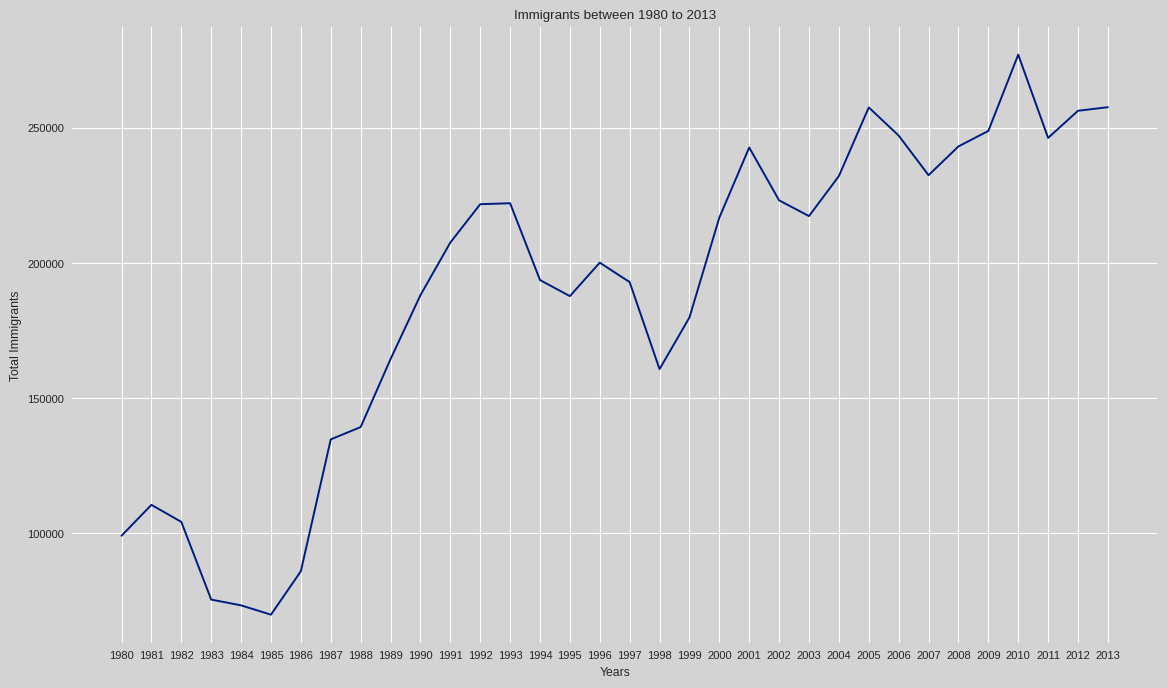

In [2]:
total_by_year = df_can[years].sum()

fig, ax = plt.subplots()
ax.plot(total_by_year)
ax.set_title("Immigrants between 1980 to 2013")
ax.set_xlabel("Years")
ax.set_ylabel("Total Immigrants")
ax.set_facecolor("lightgrey")
fig.set_size_inches((14,8))
fig.set_facecolor("lightgrey")
plt.show()

The plot function populated the x-axis with the index values (years), and the y-axis with the column values (population). <br>However, notice how the years were not displayed because they are of type string.<br> <br>Therefore, let's change the type of the index values to integer for plotting.

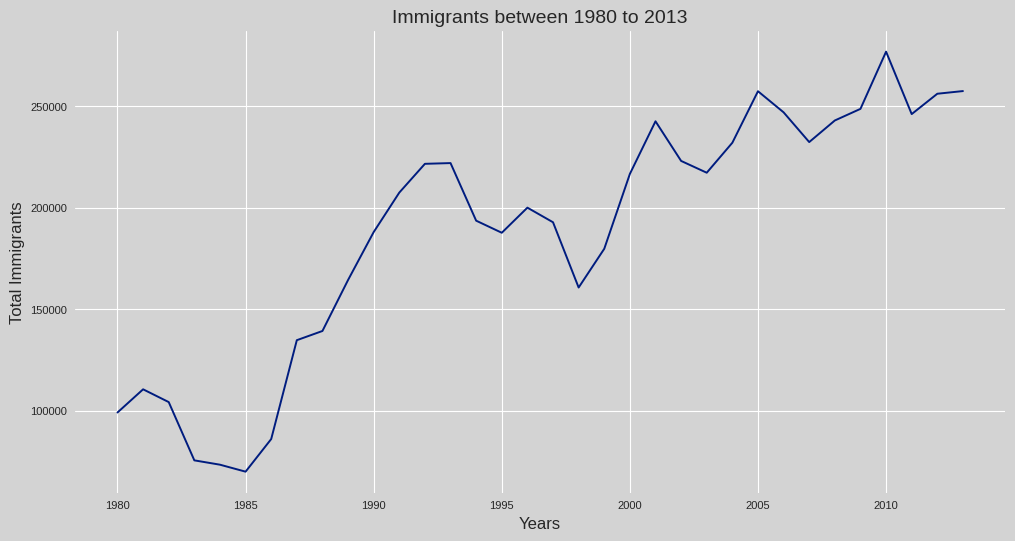

In [3]:
#Create figure and axes
fig, ax = plt.subplots()

# This tells Pandas: "Take every label in the index and run the int() function on it"
# total_by_year.index = total_by_year.index.map(int)
# Alternative to the above
total_by_year.index = total_by_year.index.astype("int")

# Plot the line
ax.plot(total_by_year)

ax.set_title("Immigrants between 1980 to 2013",fontdict={'fontsize':14})
ax.set_xlabel("Years",fontdict={'fontsize':12})
ax.set_ylabel("Total Immigrants",fontdict={'fontsize':12})
ax.set_facecolor("lightgrey")
fig.set_size_inches((12,6))
fig.set_facecolor("lightgrey")
plt.show()

More customization on the appearance.

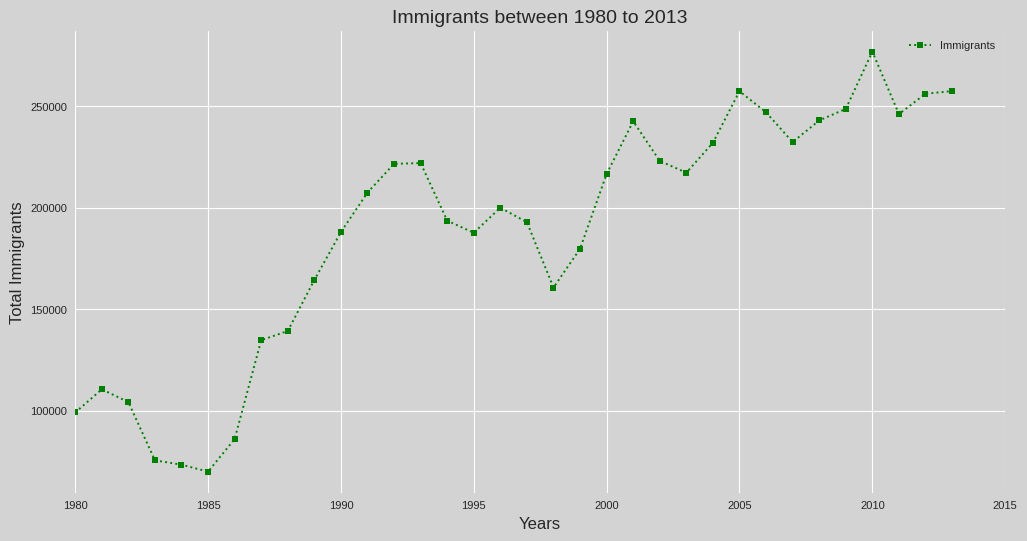

In [4]:
fig, ax = plt.subplots()

# Customizing the appearance of Plot
ax.plot(total_by_year, 
        marker='s', #Including markers in squares shapes
        markersize=5, #Setting the size of the marker
        color='green', #Changing the color of the line
        linestyle="dotted") #Changing the line style to a Dotted line

ax.set_title("Immigrants between 1980 to 2013",fontdict={'fontsize':14})
ax.set_xlabel("Years",fontdict={'fontsize':12})
ax.set_xlim(1980,2015)
ax.set_ylabel("Total Immigrants",fontdict={'fontsize':12})
ax.legend(["Immigrants"])
ax.set_facecolor("lightgrey")
# ax.grid(True)
fig.set_size_inches((12,6))
fig.set_facecolor("lightgrey")
plt.show()

Let's start with a case study:

In 2010, Haiti suffered a catastrophic magnitude 7.0 earthquake. The quake caused widespread devastation and loss of life and about three million people were affected by this natural disaster. As part of Canada's humanitarian effort, the Government of Canada stepped up its effort in accepting refugees from Haiti. We can quickly visualize this effort using a Line plot:

### Question: Plot a line graph of immigration from Haiti 

In [5]:
haiti = df_can.loc["Haiti",years]
haiti.index = haiti.index.astype("int")
haiti.head()

1980    1666
1981    3692
1982    3498
1983    2860
1984    1418
Name: Haiti, dtype: int64

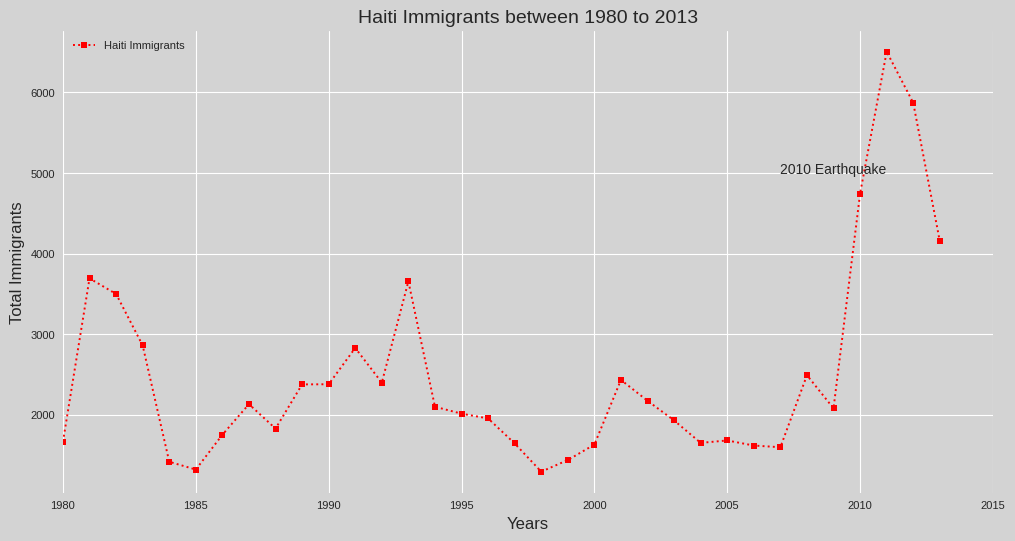

In [6]:
fig, ax = plt.subplots()

# Customizing the appearance of Plot
# Important Note: when we specify any positional parameter, then we must also separate the x and y data specification, else it gives blank canvas.
ax.plot(haiti.index, haiti.values,
        marker='s', #Including markers in squares shapes
        markersize=5, #Setting the size of the marker
        color='red', #Changing the color of the line
        linestyle="dotted") #Changing the line style to a Dotted line

ax.set_title("Haiti Immigrants between 1980 to 2013",fontdict={'fontsize':14})
ax.set_xlabel("Years",fontdict={'fontsize':12})
ax.set_xlim(1980,2015)
ax.set_ylabel("Total Immigrants",fontdict={'fontsize':12})
ax.legend(["Haiti Immigrants"],loc="upper left")
ax.set_facecolor("lightgrey")
ax.annotate('2010 Earthquake',xy=(2007, 5000))
fig.set_size_inches((12,6))
fig.set_facecolor("lightgrey")
plt.show()

## Scatter Plot
A scatter plot visualizes the relationship between two continuous variables, displaying individual data points as dots on a two-dimensional plane, allowing for the examination of patterns, clusters, and correlations.<br><br>Let's created a *Scatter plot* to visualize the immigrants (to Canada) trend during 1980 to 2013.<br>We need the Total of year-wise immigrants,<br><br>We will create a new dataframe for only columns containing the years<br> then, we will apply sum() on the dataframe<br><br>You can do create a scatter plot directly on **ax** by calling plot function **scatter()**

In [7]:
df_year_total = pd.DataFrame(df_can[years].sum(), columns=["total"])
df_year_total.reset_index(inplace=True, names=["year"])
df_year_total['year'] = df_year_total['year'].astype('int')
df_year_total.head()

,year,total
0,1980,99137
1,1981,110563
2,1982,104271
3,1983,75550
4,1984,73417


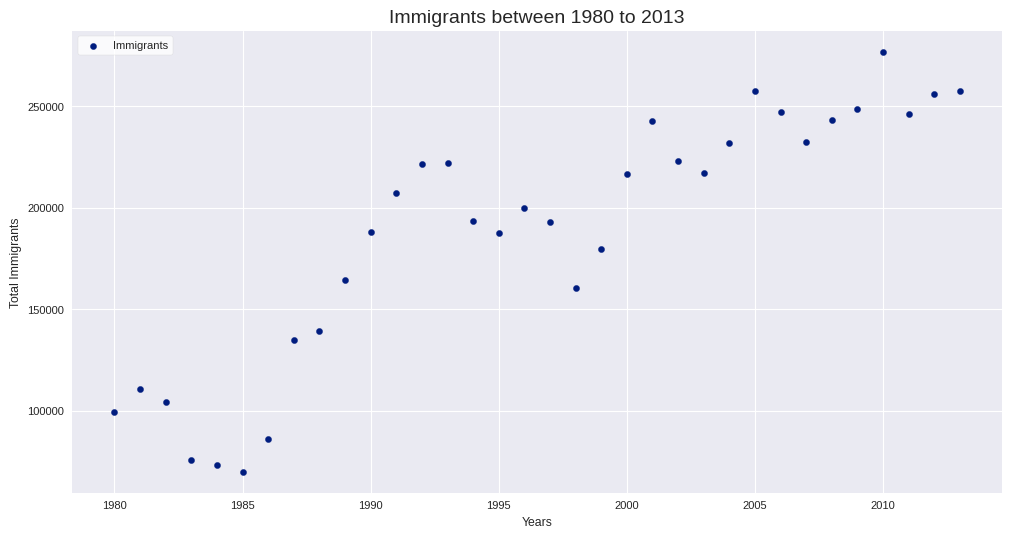

In [8]:
fig, ax = plt.subplots(figsize=(12,6)) # create figure and axes

ax.scatter(x=df_year_total["year"], y=df_year_total["total"], marker='o', s=20)
ax.set_title("Immigrants between 1980 to 2013",fontdict={'fontsize':14})
ax.set_xlabel("Years")
ax.set_ylabel("Total Immigrants")
ax.legend(["Immigrants"], loc='upper left', frameon=True, facecolor='white')
ax.grid(True)
plt.show()

## Bar Plot
A bar plot represents categorical data with rectangular bars, where the height of each bar corresponds to the value of a specific category, making it suitable for comparing values across different categories.<br><br>Let's create a bar plot to visualize the top 5 countries that contribued the most immigrants to Canada from 1980 to 2013. 
<br><br>Apply sort_values function on the 'Total' column of our data<br><br>We will create a new dataframe for only columns containing the years<br> then, we will apply sum() on the dataframe and can create a separatedataframe for top five countries<br><br>You can further use the names of the countries to label each bar on the plot

In [9]:
df_top5 = df_can.nlargest(5,'Total')[years+['Total']]
df_top5.reset_index(inplace=True)
df_top5
label = list(df_top5['Country'])
label[2] = "UK"
label

['India', 'China', 'UK', 'Philippines', 'Pakistan']

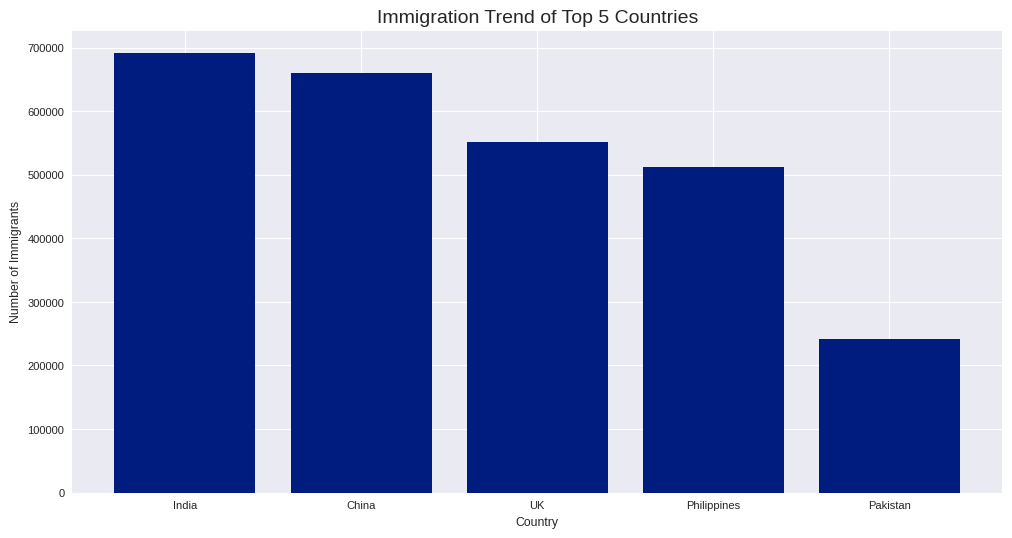

In [10]:
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(label, df_top5['Total'], label=label)
ax.set_title("Immigration Trend of Top 5 Countries",fontdict={'fontsize':14})
ax.set_xlabel('Country')
ax.set_ylabel("Number of Immigrants")
plt.show()

#### Question: Create a bar plot of the 5 countries that contributed the **least** to immigration to Canada **from** 1980 to 2013.

In [11]:
df_least5 = df_can.nsmallest(5,'Total')[years+['Total']]
df_least5.reset_index(inplace=True)
df_least5
label = list(df_least5['Country'])
label

['Palau', 'Marshall Islands', 'Western Sahara', 'New Caledonia', 'San Marino']

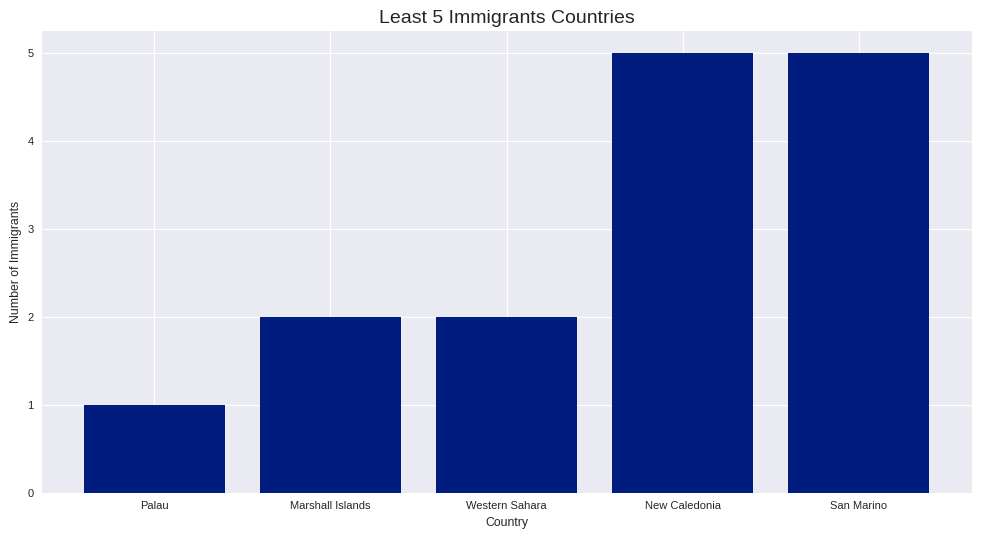

In [12]:
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(label, df_least5['Total'], label=label)
ax.set_title("Least 5 Immigrants Countries",fontdict={'fontsize':14})
ax.set_xlabel('Country')
ax.set_ylabel("Number of Immigrants")
plt.show()

### Histogram
A histogram is a way of representing the *frequency* distribution of numeric dataset. The way it works is it partitions the x-axis into *bins*, assigns each data point in our dataset to a bin, and then counts the number of data points that have been assigned to each bin. So the y-axis is the frequency or the number of data points in each bin. Note that we can change the bin size and usually one needs to tweak it so that the distribution is displayed nicely.
<br><br>Let's find out the frequency distribution of the number (population) of new immigrants from the various countries to Canada in 2013?<br>

In [13]:
df_country = df_can["2013"]
df_country = pd.DataFrame(df_country)
df_country.reset_index(names=["country"], inplace=True)
df_country.head()

,country,2013
0,Afghanistan,2004
1,Albania,603
2,Algeria,4331
3,American Samoa,0
4,Andorra,1


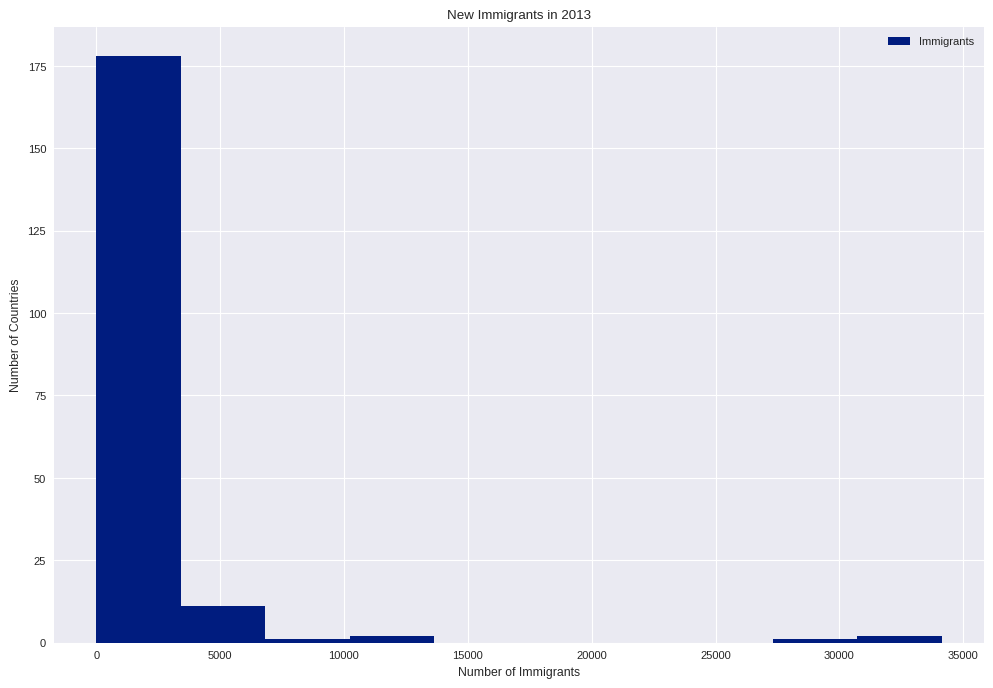

In [14]:
fig, ax = plt.subplots(figsize=(12,8))
ax.hist(df_country["2013"])
ax.set_title('New Immigrants in 2013') 
ax.set_xlabel('Number of Immigrants')
ax.set_ylabel('Number of Countries')
ax.legend(['Immigrants'])
plt.show()

Our plot does not match with the bars<br>By default, the `histrogram` method breaks up the dataset into 10 bins. The figure below summarizes the bin ranges and the frequency distribution of immigration in 2013<br> The hist function retuns list of arrays with 1. counts and 2. bins. we can fetch that using unpacking functionality <br> and further use the bins as x-ticks

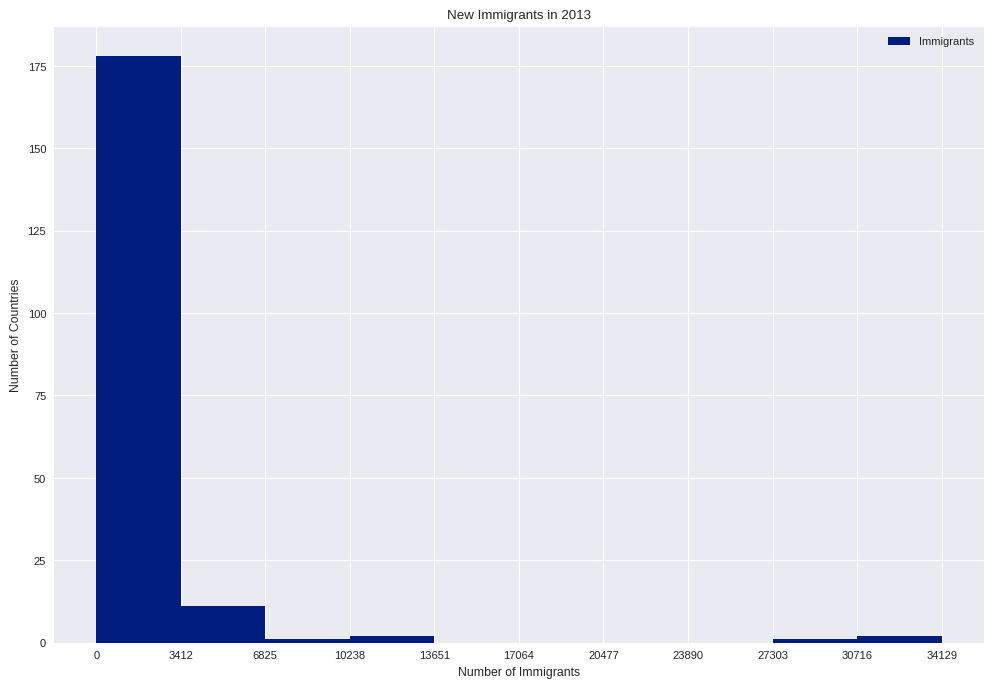

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
count = ax.hist(df_country['2013'])

#you can check the arrays in count with indexing count[0] for count, count[1] for bins

ax.set_title('New Immigrants in 2013') 
ax.set_xlabel('Number of Immigrants')
ax.set_ylabel('Number of Countries')
ax.set_xticks(list(map(int,count[1])))
ax.legend(['Immigrants'])

#Display the plot
plt.show()

#### We can also plot multiple histograms on the same plot. For example, let's try to answer the following questions using a histogram.

#### What is the immigration distribution for Denmark, Norway, and Sweden for years 1980 - 2013?

In [16]:
df=df_can.groupby(['Country'])[years].sum()
df_dns=df.loc[['Denmark', 'Norway', 'Sweden'], years]
df_dns=df_dns.T
df_dns.head()

Country,Denmark,Norway,Sweden
1980,272,116,281
1981,293,77,308
1982,299,106,222
1983,106,51,176
1984,93,31,128


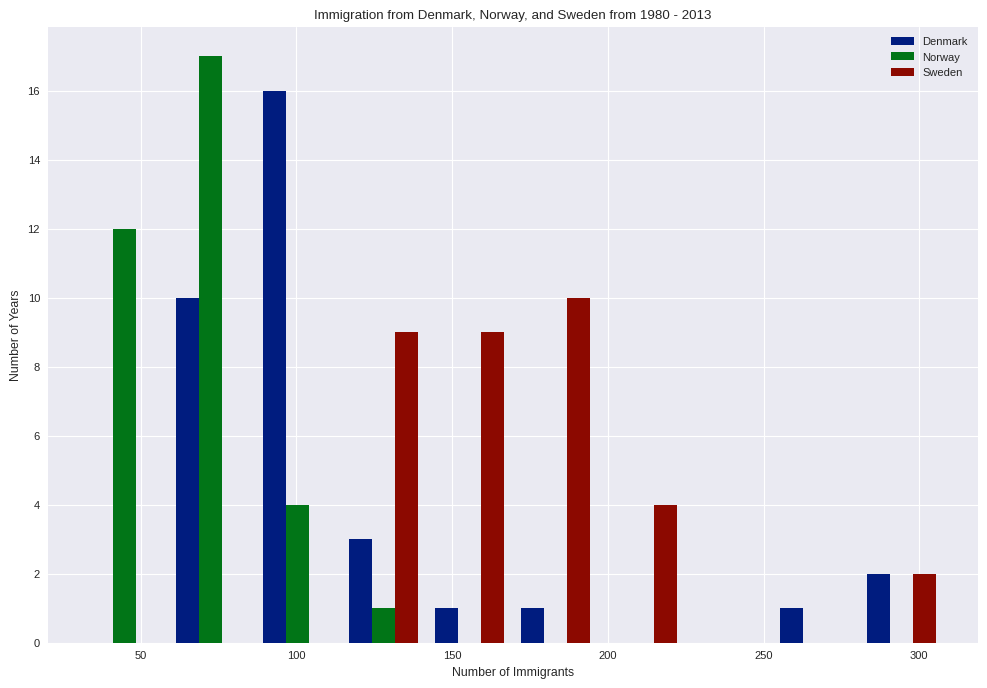

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(df_dns)
ax.set_title('Immigration from Denmark, Norway, and Sweden from 1980 - 2013') 
ax.set_xlabel('Number of Immigrants')
ax.set_ylabel('Number of Years')
ax.legend(['Denmark', 'Norway', 'Sweden'])
#Display the plot
plt.show()

#### Question: What is the immigration distribution for China and India for years 2000 to 2013?

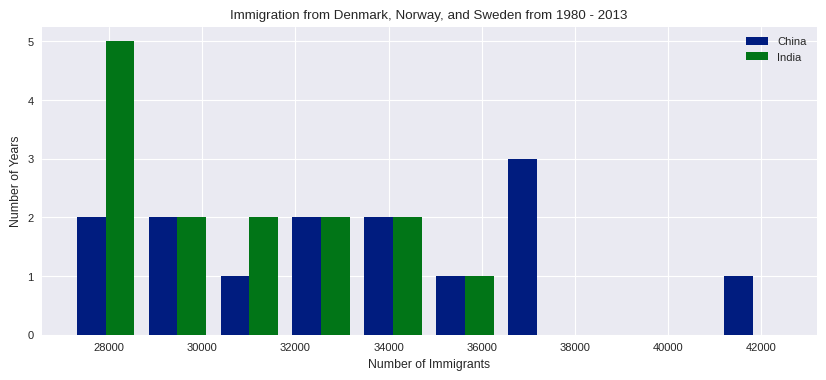

In [18]:
df=df_can.groupby(['Country'])[years].sum()
y=list(map(str,range(2000, 2014)))
df_ci=df.loc[['China', 'India'], y]
df_ci=df_ci.T
#df_ci
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_ci)
ax.set_title('Immigration from Denmark, Norway, and Sweden from 1980 - 2013') 
ax.set_xlabel('Number of Immigrants')
ax.set_ylabel('Number of Years')
ax.legend(['China', 'India'])
#Display the plot
plt.show()

### Pie Chart<a id="14"></a>

A pie chart represents the proportion or percentage distribution of different categories in a dataset using sectors of a circular pie.
<br> Let's create a pie chart representing the 'Total Immigrants' for the year 1980 to 1985

In [19]:
df_line=df_can[years]

#Applying sum to get total immigrants year-wise
total_immigrants=df_line.sum()

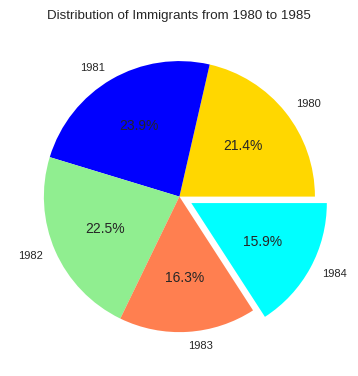

In [20]:
fig,ax=plt.subplots()

#Pie on immigrants
ax.pie(total_immigrants[0:5], labels=years[0:5], 
       colors = ['gold','blue','lightgreen','coral','cyan'],
       autopct='%1.1f%%',explode = [0,0,0,0,0.1]) #using explode to highlight the lowest 

ax.set_aspect('equal')  # Ensure pie is drawn as a circle

plt.title('Distribution of Immigrants from 1980 to 1985')
#plt.legend(years[0:5]), include legend, if you donot want to pass the labels
plt.show()

#### Question: Create a pie chart representing the total immigrants proportion for each continent

First, you will have to group the data over continents and get the sum on total. Then you can pass this data to the pie function

In [21]:
#Creating data for plotting pie
df_con=df_can.groupby('Continent')['Total'].sum().reset_index()
label=list(df_con.Continent)
label[3] = 'LAC'
label[4] = 'NA'
df_con

,Continent,Total
0,Africa,618948
1,Asia,3317794
2,Europe,1410947
3,Latin America and the Caribbean,765148
4,Northern America,241142
5,Oceania,55174


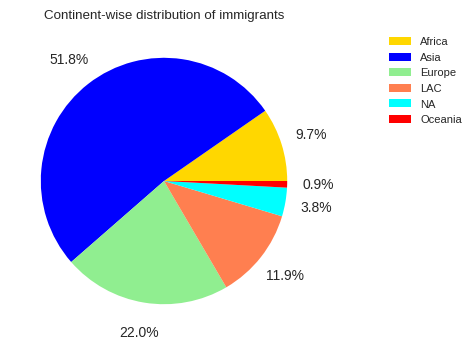

In [22]:
fig,ax=plt.subplots(figsize=(10, 4))

#Pie on immigrants
ax.pie(df_con['Total'], colors = ['gold','blue','lightgreen','coral','cyan','red'],
        autopct='%1.1f%%', pctdistance=1.25)

ax.set_aspect('equal')  # Ensure pie is drawn as a circle
plt.title('Continent-wise distribution of immigrants')
ax.legend(label,bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

### Sub-plotting

Let us explore how to display more than one plot on the same figure and specify the number of rows and columns to be created to the subplots function.  

For instance, let’s create a line and scatter plot in one row <br>
plt.subplots() <br>
You can use the same functions using which you plotte lne and scatter plots at the start of this lab
<br>
Both the subplots will be sharing the same y-axis as the data in the y-axis is the same. So, assign the ‘Sharey’ parameter as True in the code below. Also notice the use of 'suptitle'

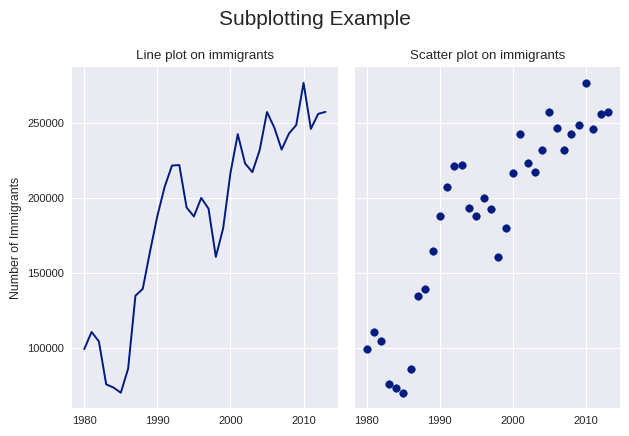

In [23]:
total_immigrants.index = total_immigrants.index.astype("int")

fig, axs = plt.subplots(1, 2, sharey=True)

#Plotting in first axes - the left one
axs[0].plot(total_immigrants)
axs[0].set_title("Line plot on immigrants")

#Plotting in second axes - the right one
axs[1].scatter(total_immigrants.index, total_immigrants)
axs[1].set_title("Scatter plot on immigrants")

axs[0].set_ylabel("Number of Immigrants")
            
#Adding a Title for the Overall Figure
fig.suptitle('Subplotting Example', fontsize=15)

# Adjust spacing between subplots
fig.tight_layout()


# Show the figure
plt.show()

You can also implement the subplotting with **add_subplot()** as below:-

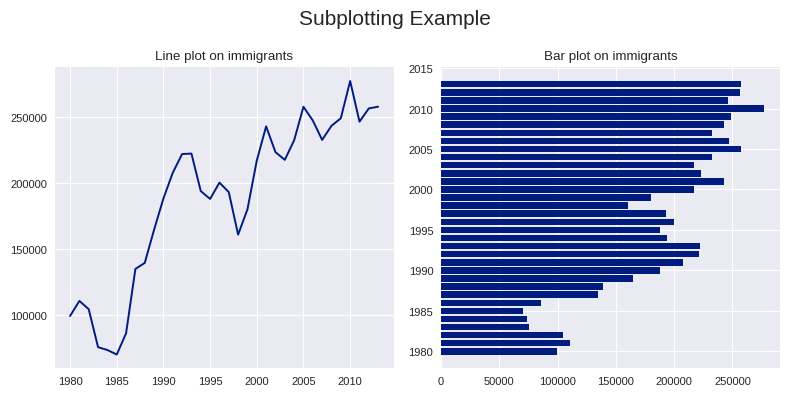

In [24]:
# Create a figure with Four axes - two rows, two columns
fig = plt.figure(figsize=(8,4))

# Add the first subplot (top-left)
axs1 = fig.add_subplot(1, 2, 1)
#Plotting in first axes - the left one
axs1.plot(total_immigrants)
axs1.set_title("Line plot on immigrants")

# Add the second subplot (top-right)
axs2 = fig.add_subplot(1, 2, 2)
#Plotting in second axes - the right one
axs2.barh(total_immigrants.index, total_immigrants) #Notice the use of 'barh' for creating horizontal bar plot
axs2.set_title("Bar plot on immigrants")
            
#Adding a Title for the Overall Figure
fig.suptitle('Subplotting Example', fontsize=15)

# Adjust spacing between subplots
fig.tight_layout()


# Show the figure
plt.show()

#### Question: Choose any four plots, which you have developed in this lab, with subplotting display them in a 2x2 display

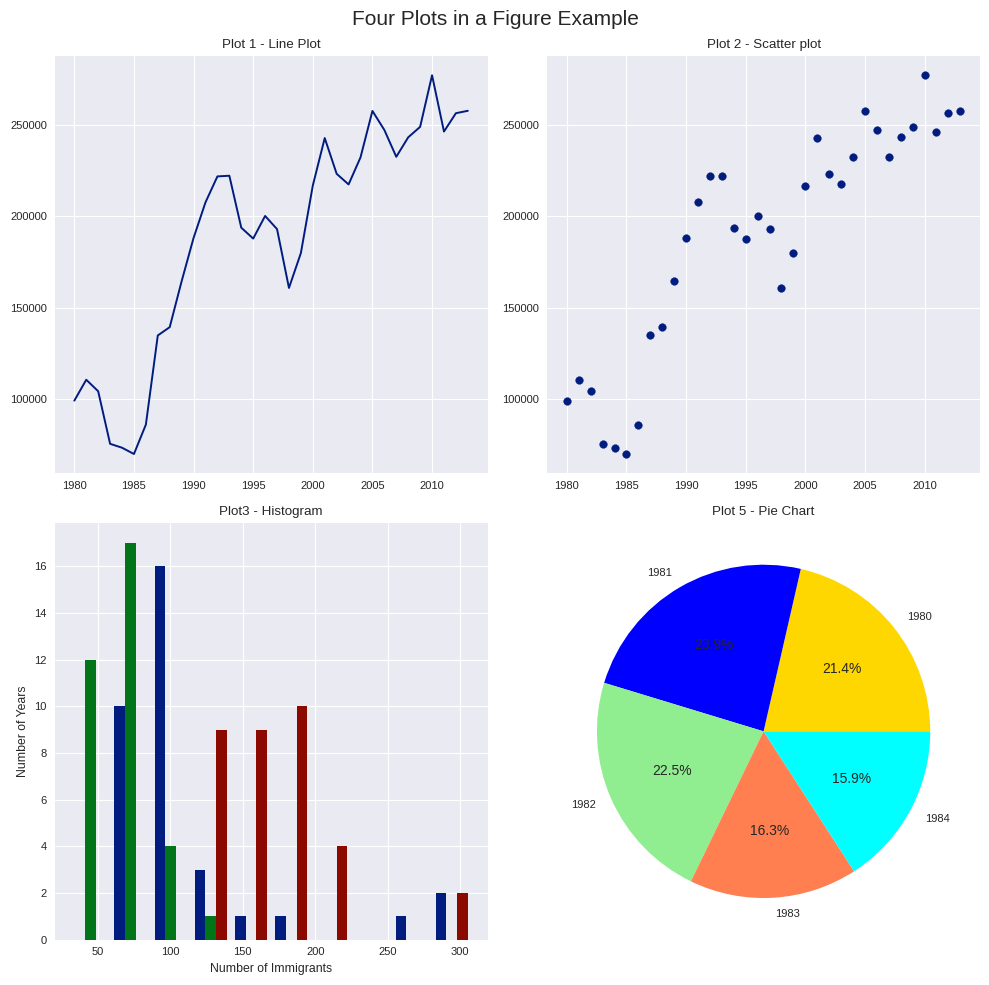

In [25]:
# Create a figure with Four axes - two rows, two columns
fig = plt.figure(figsize=(10, 10))

# Add the first subplot (top-left)
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(total_immigrants)
ax1.set_title('Plot 1 - Line Plot')

# Add the second subplot (top-right)
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(total_immigrants.index, total_immigrants)
ax2.set_title('Plot 2 - Scatter plot')

# Add the third subplot (bottom-left)
ax3 = fig.add_subplot(2, 2, 3)
ax3.hist(df_dns)
ax3.set_title('Plot3 - Histogram') 
ax3.set_xlabel('Number of Immigrants')
ax3.set_ylabel('Number of Years')

# Add the fourth subplot (bottom-right)
ax4 = fig.add_subplot(2, 2, 4)
ax4.pie(total_immigrants[0:5], labels=years[0:5], 
        colors = ['gold','blue','lightgreen','coral','cyan'],
        autopct='%1.1f%%')
ax4.set_aspect('equal')  
ax4.set_title('Plot 5 - Pie Chart')

#Adding a Title for the Overall Figure
fig.suptitle('Four Plots in a Figure Example', fontsize=15)

# Adjust spacing between subplots
fig.tight_layout()


# Show the figure
plt.show()